# Fase 3 - Preprocesamiento de Datos (Videojuegos)

Este notebook implementa un pipeline reproducible de preprocesamiento a partir del EDA de Fase 2.

## Objetivos
- Estandarizar tipos y formatos.
- Tratar faltantes con reglas segmentadas.
- Generar variables listas para modelado.
- Exportar datasets procesados para la siguiente etapa.

In [3]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [4]:
# Rutas base del proyecto
ROOT = Path('..')
DATASET_RAW = ROOT / 'datasets' / 'Video Games Sales (1980-2024) - Raw.csv'
OUTPUT_DIR = ROOT / 'datasets'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATASET_RAW)
print('Dataset cargado:', DATASET_RAW)
print('Dimensiones:', df.shape)
df.head(3)

Dataset cargado: ..\datasets\Video Games Sales (1980-2024) - Raw.csv
Dimensiones: (64016, 14)


,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,17-09-2013,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,18-11-2014,03-01-2018
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,28-10-2002,NaN


## 1. Estandarizacion inicial

In [5]:
df_prep = df.copy()

# Normalizacion de strings
for col in ['title', 'console', 'genre', 'publisher', 'developer']:
    df_prep[col] = df_prep[col].astype(str).str.strip()
    df_prep[col] = df_prep[col].replace({'': np.nan, 'nan': np.nan})

# Fechas
df_prep['release_date'] = pd.to_datetime(df_prep['release_date'], format='%d-%m-%Y', errors='coerce')
df_prep['release_year'] = df_prep['release_date'].dt.year

# Columnas numericas
num_cols = ['critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'release_year']
for col in num_cols:
    df_prep[col] = pd.to_numeric(df_prep[col], errors='coerce')

# Valores negativos no tienen sentido para ventas
sales_cols = ['total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales']
for col in sales_cols:
    df_prep.loc[df_prep[col] < 0, col] = np.nan

df_prep[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
critic_score,6678.0,7.220440,1.457066,1.0,6.40,7.50,8.30,10.00
total_sales,18922.0,0.349113,0.807462,0.0,0.03,0.12,0.34,20.32
na_sales,12637.0,0.264740,0.494787,0.0,0.05,0.12,0.28,9.76
jp_sales,6726.0,0.102281,0.168811,0.0,0.02,0.04,0.12,2.13
pal_sales,12824.0,0.149472,0.392653,0.0,0.01,0.04,0.14,9.85
other_sales,15128.0,0.043041,0.126643,0.0,0.00,0.01,0.03,3.12
release_year,56965.0,2006.359572,8.617813,1971.0,2001.00,2008.00,2012.00,2024.00


## 2. Perfil de faltantes antes de imputar

In [6]:
missing_before = pd.DataFrame({
    'missing_count': df_prep.isna().sum(),
    'missing_pct': (df_prep.isna().mean() * 100).round(2)
}).sort_values('missing_pct', ascending=False)

missing_before.head(12)

,missing_count,missing_pct
critic_score,57338,89.57
jp_sales,57290,89.49
na_sales,51379,80.26
pal_sales,51192,79.97
other_sales,48888,76.37
last_update,46137,72.07
total_sales,45094,70.44
release_date,7051,11.01
release_year,7051,11.01
developer,17,0.03


## 3. Banderas de faltantes (se conserva señal)

In [7]:
critical_missing_cols = ['critic_score', 'release_year', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales']
for col in critical_missing_cols:
    df_prep[f'flag_missing_{col}'] = df_prep[col].isna().astype('int8')

df_prep[[f'flag_missing_{c}' for c in critical_missing_cols]].mean().sort_values(ascending=False)

flag_missing_critic_score    0.895682
flag_missing_jp_sales        0.894933
flag_missing_na_sales        0.802596
flag_missing_pal_sales       0.799675
flag_missing_other_sales     0.763684
flag_missing_release_year    0.110144
dtype: float64

## 4. Imputacion segmentada

In [8]:
# 4.1 critic_score: mediana por (genre, console), luego por genre, luego mediana global
group_gc = df_prep.groupby(['genre', 'console'])['critic_score'].transform('median')
group_g = df_prep.groupby('genre')['critic_score'].transform('median')
global_critic = df_prep['critic_score'].median()

df_prep['critic_score'] = df_prep['critic_score'].fillna(group_gc).fillna(group_g).fillna(global_critic)

# 4.2 release_year: mediana por consola, luego mediana global
year_console = df_prep.groupby('console')['release_year'].transform('median')
global_year = int(round(df_prep['release_year'].median()))
df_prep['release_year'] = df_prep['release_year'].fillna(year_console).fillna(global_year)
df_prep['release_year'] = df_prep['release_year'].round().astype('int16')

# 4.3 Ventas regionales: imputacion proporcional cuando total_sales existe
region_cols = ['na_sales', 'jp_sales', 'pal_sales', 'other_sales']
known_regions = df_prep[region_cols].notna().all(axis=1) & df_prep['total_sales'].notna() & (df_prep['total_sales'] > 0)

for col in region_cols:
    df_prep[f'{col}_share'] = np.where(known_regions, df_prep[col] / df_prep['total_sales'], np.nan)

share_gc = {col: df_prep.groupby(['genre', 'console'])[f'{col}_share'].transform('median') for col in region_cols}
share_global = {col: df_prep[f'{col}_share'].median() for col in region_cols}

for col in region_cols:
    cond = df_prep[col].isna() & df_prep['total_sales'].notna() & (df_prep['total_sales'] >= 0)
    est_share = share_gc[col].fillna(share_global[col])
    df_prep.loc[cond, col] = df_prep.loc[cond, 'total_sales'] * est_share[cond]

# Si total_sales es nulo pero hay ventas regionales, reconstruir total
sum_regions = df_prep[region_cols].sum(axis=1, min_count=1)
df_prep['total_sales'] = df_prep['total_sales'].fillna(sum_regions)

# Limpieza de columnas auxiliares
drop_share_cols = [f'{col}_share' for col in region_cols]
df_prep.drop(columns=drop_share_cols, inplace=True)

df_prep[region_cols + ['total_sales', 'critic_score', 'release_year']].isna().mean().mul(100).round(2)

na_sales        70.44
jp_sales        70.44
pal_sales       70.44
other_sales     70.44
total_sales     70.44
critic_score     0.00
release_year     0.00
dtype: float64

## 5. Tratamiento de outliers para modelado

In [9]:
# Se preserva el valor original y se crea version capped (winsorizacion al p99)
for col in ['total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales']:
    p99 = df_prep[col].quantile(0.99)
    df_prep[f'{col}_capped'] = np.where(df_prep[col].notna(), np.minimum(df_prep[col], p99), np.nan)

df_prep[[c for c in df_prep.columns if c.endswith('_capped')]].describe().T

,count,mean,std,min,25%,50%,75%,max
total_sales_capped,18922.0,0.323403,0.565217,0.0,0.030000,0.120000,0.340000,3.540000
na_sales_capped,18922.0,0.175864,0.312195,0.0,0.016898,0.065333,0.180000,1.940000
jp_sales_capped,18922.0,0.056811,0.101828,0.0,0.004116,0.020000,0.060000,0.609145
pal_sales_capped,18922.0,0.097671,0.204944,0.0,0.006559,0.023367,0.088608,1.330000
other_sales_capped,18922.0,0.031602,0.069167,0.0,0.000000,0.010000,0.030000,0.460000


## 6. Variables derivadas

In [10]:
# Transformaciones utiles para modelos
df_prep['log_total_sales'] = np.log1p(df_prep['total_sales'])

# Decada de lanzamiento como variable categorica ordenable
df_prep['release_decade'] = (df_prep['release_year'] // 10) * 10

# Comprobacion de consistencia entre total y suma de regiones
df_prep['sum_regional_sales'] = df_prep[['na_sales', 'jp_sales', 'pal_sales', 'other_sales']].sum(axis=1, min_count=1)
df_prep['gap_total_vs_regions'] = (df_prep['total_sales'] - df_prep['sum_regional_sales']).round(4)

df_prep[['log_total_sales', 'release_decade', 'gap_total_vs_regions']].head()

,log_total_sales,release_decade,gap_total_vs_regions
0,3.059646,2010,-0.01
1,3.015045,2010,0.00
2,2.841998,2000,-0.00
3,2.824944,2010,-0.01
4,2.778198,2010,0.01


## 7. Validaciones finales

In [11]:
checks = {
    'sin_ventas_negativas': bool((df_prep[['total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales']] < 0).sum().sum() == 0),
    'critic_score_sin_nulos': bool(df_prep['critic_score'].isna().sum() == 0),
    'release_year_sin_nulos': bool(df_prep['release_year'].isna().sum() == 0),
    'total_sales_sin_nulos': bool(df_prep['total_sales'].isna().sum() == 0)
}

pd.Series(checks, name='resultado')

sin_ventas_negativas       True
critic_score_sin_nulos     True
release_year_sin_nulos     True
total_sales_sin_nulos     False
Name: resultado, dtype: bool

## 8. Codificacion categorica y escalado numerico

Se aplican transformaciones base para modelado:
- One-Hot Encoding para variables categoricas.
- Estandarizacion (`StandardScaler`) para variables numericas.

In [12]:
from scipy import sparse

categorical_cols = ['console', 'genre', 'publisher']
numeric_model_cols = [
    'critic_score', 'release_year',
    'total_sales_capped', 'na_sales_capped', 'jp_sales_capped', 'pal_sales_capped', 'other_sales_capped',
    'log_total_sales'
 ]

df_features = df_prep[categorical_cols + numeric_model_cols].copy()
for col in categorical_cols:
    df_features[col] = df_features[col].fillna('Unknown').astype(str)

# Imputacion final para evitar NaN en transformaciones de sklearn
for col in numeric_model_cols:
    df_features[col] = pd.to_numeric(df_features[col], errors='coerce')
    df_features[col] = df_features[col].fillna(df_features[col].median())

# Mantener matriz dispersa para evitar errores de memoria
try:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
except TypeError:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse=True)

X_cat_sparse = encoder.fit_transform(df_features[categorical_cols])
cat_feature_names = encoder.get_feature_names_out(categorical_cols)

scaler = StandardScaler()
X_num = scaler.fit_transform(df_features[numeric_model_cols]).astype(np.float32)
X_num_sparse = sparse.csr_matrix(X_num)

X_processed_sparse = sparse.hstack([X_num_sparse, X_cat_sparse], format='csr')
feature_names = np.array(list(numeric_model_cols) + list(cat_feature_names))

density = X_processed_sparse.nnz / (X_processed_sparse.shape[0] * X_processed_sparse.shape[1])
print('Shape matriz procesada (sparse):', X_processed_sparse.shape)
print('Densidad de la matriz:', round(density, 6))
print('Variables totales codificadas:', len(feature_names))

Shape matriz procesada (sparse): (64016, 3492)
Densidad de la matriz: 0.00315
Variables totales codificadas: 3492


## 9. Reduccion de dimensionalidad (TruncatedSVD)

Como la codificacion categorica genera una matriz de alta dimensionalidad y dispersa, se usa TruncatedSVD (alternativa adecuada a PCA para datos sparse).

Componentes calculados: 150
Componentes para ~90% varianza: 38
Varianza acumulada final: 0.9659


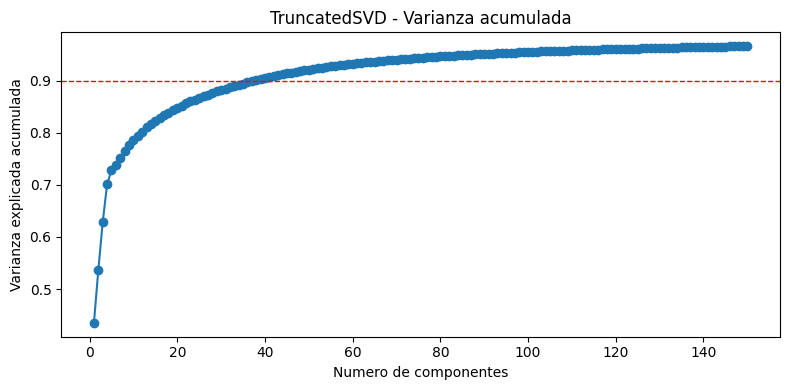

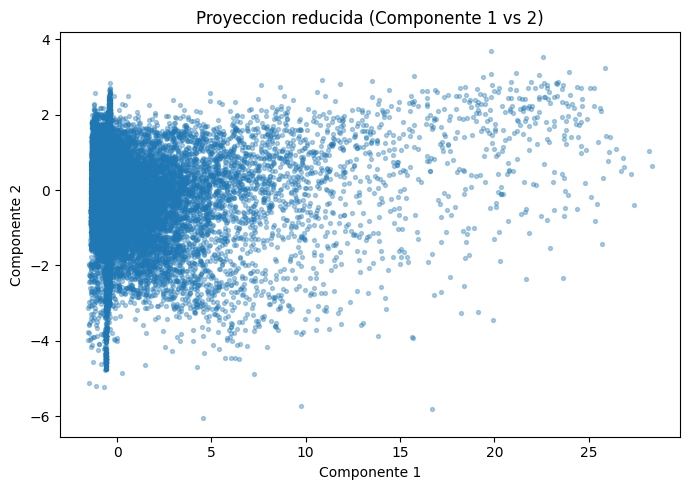

,PC1,PC2,PC3,PC4,PC5
0,28.338646,0.633930,1.739071,3.884513,-0.528493
1,28.191685,1.022303,1.952519,3.775826,-0.519709


In [13]:
from sklearn.decomposition import TruncatedSVD

# Limite de componentes para mantener costo computacional razonable
max_components = min(150, X_processed_sparse.shape[1] - 1)
svd = TruncatedSVD(n_components=max_components, random_state=42)
X_reduced = svd.fit_transform(X_processed_sparse)

cum_var = np.cumsum(svd.explained_variance_ratio_)
n_90 = int(np.argmax(cum_var >= 0.90) + 1) if np.any(cum_var >= 0.90) else len(cum_var)

print('Componentes calculados:', max_components)
print('Componentes para ~90% varianza:', n_90)
print('Varianza acumulada final:', round(cum_var[-1], 4))

pc_cols = [f'PC{i+1}' for i in range(X_reduced.shape[1])]
df_pca = pd.DataFrame(X_reduced, columns=pc_cols, index=df_prep.index)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o')
plt.axhline(0.90, color='red', linestyle='--', linewidth=1)
plt.title('TruncatedSVD - Varianza acumulada')
plt.xlabel('Numero de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.tight_layout()
plt.show()

if X_reduced.shape[1] >= 2:
    plt.figure(figsize=(7, 5))
    plt.scatter(df_pca['PC1'], df_pca['PC2'], s=8, alpha=0.35)
    plt.title('Proyeccion reducida (Componente 1 vs 2)')
    plt.xlabel('Componente 1')
    plt.ylabel('Componente 2')
    plt.tight_layout()
    plt.show()

df_pca.iloc[:, :min(5, df_pca.shape[1])].head(2)